In [1]:
from mascon_cube.data.datasets import create_trajectory_dataset, create_random_dataset
from torch.utils.data import DataLoader
import torch
from mascon_cube.constants import VAL_DATASETS_DIR
from mascon_cube.training import training_loop, CubeTrainingConfig, ValidationConfig, LogConfig

In [2]:
asteroid = "eros_3"


In [ ]:
create_trajectory_dataset(asteroid, 60*24*60//5, propagation_days=10) # every 5 seconds for 24 hours

(1.5, 0.0, 1.57075, 0.0, 0.0, 1.57075)


PosixPath('/home/pietrofanti/code/masconCube/data/train_datasets/eros_trajectory_1_17280_1759146619.pt')

In [7]:
create_random_dataset(asteroid, 60*24*60//5, sampling_max=2)

PosixPath('/home/pietrofanti/code/masconCube/data/train_datasets/eros_3_17280_spherical_0.0_2_42.pt')

In [6]:
config = CubeTrainingConfig(asteroid=asteroid, train_set_path='/home/pietrofanti/code/masconCube/data/train_datasets/eros_trajectory_17280_1758896005.pt')
device = "cuda" if torch.cuda.is_available() else "cpu"

val_dataset = torch.load(VAL_DATASETS_DIR / f"{asteroid}_1000_spherical_0_2.pt").to(
    device
)
val_config = ValidationConfig(val_dataset=val_dataset, val_every_n_epochs=1)
log_config = None

cube = training_loop(config, val_config, log_config, device=device, progressbar=True)

Training: 100%|██████████| 10/10 [02:04<00:00, 12.43s/epoch]


In [8]:
config = CubeTrainingConfig(asteroid=asteroid, train_set_path='/home/pietrofanti/code/masconCube/data/train_datasets/eros_3_17280_spherical_0.0_2_42.pt')
device = "cuda" if torch.cuda.is_available() else "cpu"

cube2 = training_loop(config, val_config, log_config, device=device, progressbar=True)

Training: 100%|██████████| 10/10 [02:00<00:00, 12.04s/epoch]


In [6]:
from mascon_cube.visualization import plot_trajectory, plot_mascon_cube

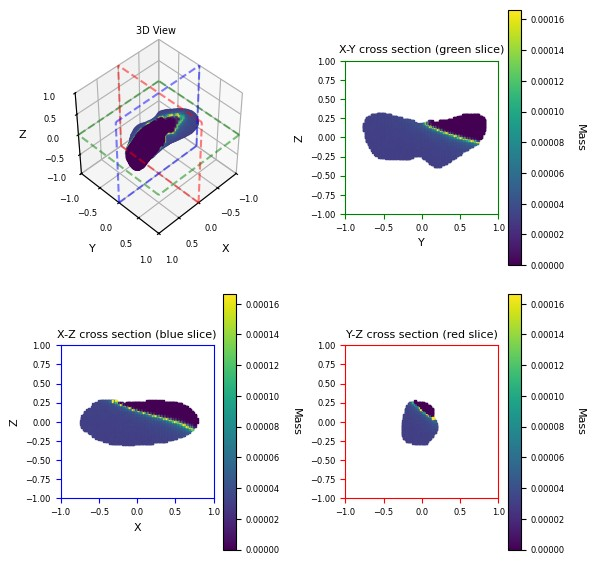

In [12]:
plot_mascon_cube(cube);

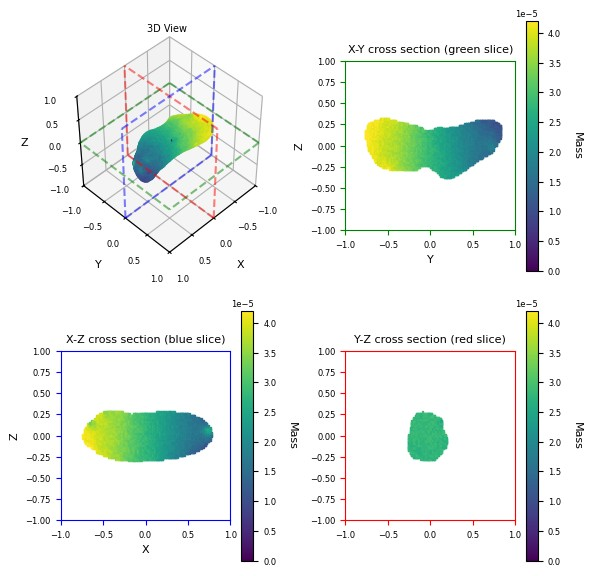

In [13]:
plot_mascon_cube(cube2);

In [7]:
from mascon_cube.data.datasets import AccelerationDataset
trajectory = AccelerationDataset('/home/pietrofanti/code/masconCube/data/train_datasets/eros_trajectory_1_17280_1759146619.pt')

In [11]:
import numpy as np

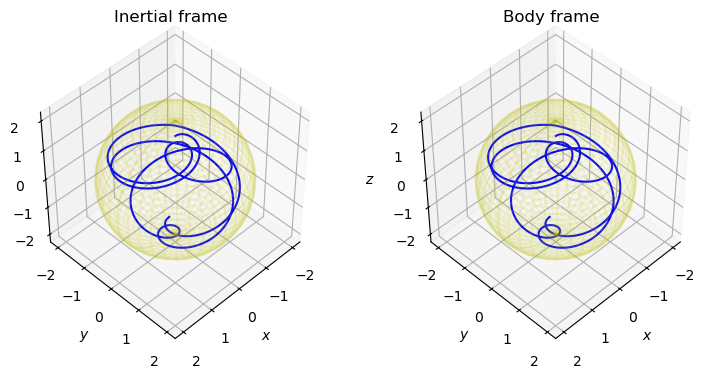

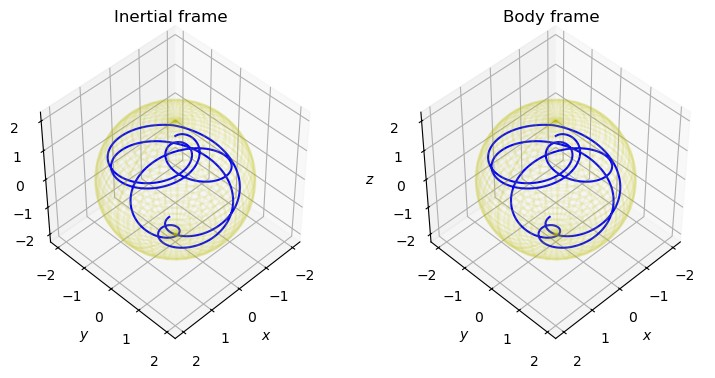

In [12]:
plot_trajectory(trajectory.data[:,:3], trajectory.data[:,:3], np.zeros([3,3]))